# 04 Clean Markdown and Inspect

## Σκοπός
Σε αυτό το notebook:

- φορτώνουμε τα markdown αρχεία που παρήχθησαν από το Docling
- επιθεωρούμε την ποιότητά τους
- εντοπίζουμε κοινά extraction artifacts
- εφαρμόζουμε βασικούς κανόνες καθαρισμού
- αποθηκεύουμε cleaned markdown αρχεία
- δημιουργούμε cleaning manifest

Στόχος είναι να προετοιμάσουμε τα κείμενα για το επόμενο στάδιο του chunking.
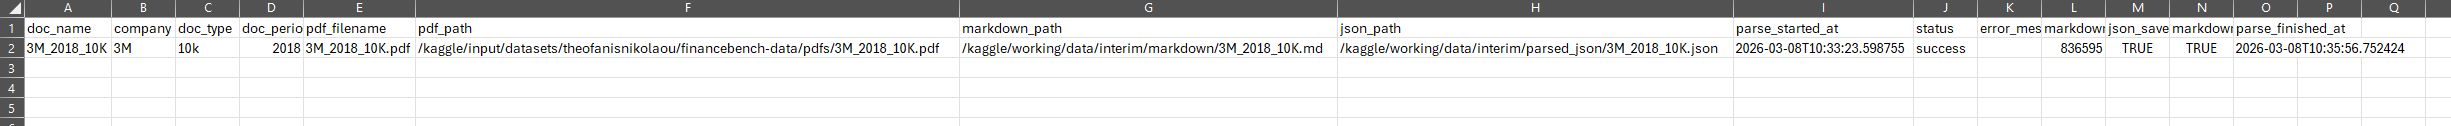

In [1]:
from pathlib import Path
import re
import json
import warnings
from collections import Counter

import pandas as pd
from tqdm.auto import tqdm

C:\Users\ntheo\Desktop\Repositories\CV_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)

IN_KAGGLE = Path("/kaggle/working").exists()
print("IN_KAGGLE:", IN_KAGGLE)

IN_KAGGLE: False


In [3]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUTS_DIR = BASE_DIR / "outputs"

MARKDOWN_DIR = INTERIM_DIR / "markdown"
CLEANED_DIR = INTERIM_DIR / "cleaned"
LOGS_DIR = OUTPUTS_DIR / "logs"

PARSE_MANIFEST_PATH = INTERIM_DIR / "docling_parse_manifest.csv"
CLEANING_MANIFEST_PATH = INTERIM_DIR / "markdown_cleaning_manifest.csv"

for p in [CLEANED_DIR, OUTPUTS_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("MARKDOWN_DIR:", MARKDOWN_DIR)
print("CLEANED_DIR:", CLEANED_DIR)
print("PARSE_MANIFEST_PATH exists:", PARSE_MANIFEST_PATH.exists())

MARKDOWN_DIR: C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown
CLEANED_DIR: C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned
PARSE_MANIFEST_PATH exists: True


In [4]:
parse_manifest_df = pd.read_csv(PARSE_MANIFEST_PATH)

print("parse_manifest_df shape:", parse_manifest_df.shape)
parse_manifest_df.head(2)

parse_manifest_df shape: (84, 15)


,doc_name,company,doc_type,doc_period,pdf_filename,pdf_path,markdown_path,json_path,parse_started_at,status,error_message,markdown_chars,json_saved,markdown_saved,parse_finished_at
0,3M_2018_10K,3M,10k,2018,3M_2018_10K.pdf,/kaggle/input/datasets/theofanisnikolaou/financebench-data/pdfs/3M_2018_10K.pdf,/kaggle/working/data/interim/markdown/3M_2018_10K.md,/kaggle/working/data/interim/parsed_json/3M_2018_10K.json,2026-03-08T18:11:07.828348,success,NaN,836595,True,True,2026-03-08T18:13:39.922772
1,3M_2022_10K,3M,10k,2022,3M_2022_10K.pdf,/kaggle/input/datasets/theofanisnikolaou/financebench-data/pdfs/3M_2022_10K.pdf,/kaggle/working/data/interim/markdown/3M_2022_10K.md,/kaggle/working/data/interim/parsed_json/3M_2022_10K.json,2026-03-08T18:13:39.924284,success,NaN,1183135,True,True,2026-03-08T18:16:31.042402


In [5]:
successful_df = parse_manifest_df[parse_manifest_df["status"] == "success"].copy().reset_index(drop=True)

print("Successful parsed docs:", len(successful_df))
successful_df.head(2)

Successful parsed docs: 84


,doc_name,company,doc_type,doc_period,pdf_filename,pdf_path,markdown_path,json_path,parse_started_at,status,error_message,markdown_chars,json_saved,markdown_saved,parse_finished_at
0,3M_2018_10K,3M,10k,2018,3M_2018_10K.pdf,/kaggle/input/datasets/theofanisnikolaou/financebench-data/pdfs/3M_2018_10K.pdf,/kaggle/working/data/interim/markdown/3M_2018_10K.md,/kaggle/working/data/interim/parsed_json/3M_2018_10K.json,2026-03-08T18:11:07.828348,success,NaN,836595,True,True,2026-03-08T18:13:39.922772
1,3M_2022_10K,3M,10k,2022,3M_2022_10K.pdf,/kaggle/input/datasets/theofanisnikolaou/financebench-data/pdfs/3M_2022_10K.pdf,/kaggle/working/data/interim/markdown/3M_2022_10K.md,/kaggle/working/data/interim/parsed_json/3M_2022_10K.json,2026-03-08T18:13:39.924284,success,NaN,1183135,True,True,2026-03-08T18:16:31.042402


In [6]:
md_files = sorted(MARKDOWN_DIR.glob("*.md"))

print("Markdown files found:", len(md_files))
for f in md_files[:10]:
    print("-", f.name)

Markdown files found: 84
- 3M_2018_10K.md
- 3M_2022_10K.md
- 3M_2023Q2_10Q.md
- ACTIVISIONBLIZZARD_2019_10K.md
- ADOBE_2015_10K.md
- ADOBE_2016_10K.md
- ADOBE_2017_10K.md
- ADOBE_2022_10K.md
- AES_2022_10K.md
- AMAZON_2017_10K.md


In [7]:
md_inventory = pd.DataFrame({
    "markdown_filename": [p.name for p in md_files],
    "markdown_path": [str(p) for p in md_files],
    "markdown_stem": [p.stem for p in md_files]
})

md_inventory.head()

,markdown_filename,markdown_path,markdown_stem
0,3M_2018_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2018_10K.md,3M_2018_10K
1,3M_2022_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2022_10K.md,3M_2022_10K
2,3M_2023Q2_10Q.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2023Q2_10Q.md,3M_2023Q2_10Q
3,ACTIVISIONBLIZZARD_2019_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\ACTIVISIONBLIZZARD_2019_10K.md,ACTIVISIONBLIZZARD_2019_10K
4,ADOBE_2015_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\ADOBE_2015_10K.md,ADOBE_2015_10K


In [8]:
def read_text(path: Path) -> str:
    return path.read_text(encoding="utf-8")

In [9]:
sample_path = md_files[0] if md_files else None

if sample_path:
    sample_text = read_text(sample_path)
    print("Sample file:", sample_path.name)
    print(sample_text[:4000])
else:
    print("No markdown files found.")

Sample file: 3M_2018_10K.md
low

## UNITED STATES SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

## FORM 10-K

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended December 31, 2018

Commission file number 1-3285

## 3M COMPANY

State of Incorporation:

Delaware

I.R.S. Employer Identification No.

41-0417775

Principal executive offices:

3M Center, St. Paul, Minnesota 55144

Telephone number:

(651) 733-1110

## SECURITIES REGISTERED PURSUANT TO SECTION 12(b) OF THE ACT:

Name of each exchange

## Title of each class

on which registered

Common Stock, Par Value $.01 Per Share

1.500% Notes due 2026

Floating Rate Notes due 2020

0.375% Notes due 2022

0.950% Notes due 2023

1.750% Notes due 2030

1.500% Notes due 2031

New York Stock Exchange, Inc.

Chicago Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York S

In [10]:
md_inventory["char_count"] = md_inventory["markdown_path"].apply(lambda x: len(read_text(Path(x))))
md_inventory["line_count"] = md_inventory["markdown_path"].apply(lambda x: len(read_text(Path(x)).splitlines()))

md_inventory.describe(include="all")

,markdown_filename,markdown_path,markdown_stem,char_count,line_count
count,84,84,84,8.400000e+01,84.000000
unique,84,84,84,NaN,NaN
top,3M_2018_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2018_10K.md,3M_2018_10K,NaN,NaN
freq,1,1,1,NaN,NaN
mean,NaN,NaN,NaN,6.470237e+05,4096.309524
std,NaN,NaN,NaN,4.049457e+05,2532.692762
min,NaN,NaN,NaN,7.782000e+03,128.000000
25%,NaN,NaN,NaN,4.313860e+05,2749.750000
50%,NaN,NaN,NaN,6.142045e+05,3896.500000
75%,NaN,NaN,NaN,8.300370e+05,4932.500000


In [11]:
patterns = {
    "checkbox_unchecked": r"\- \[ \]",
    "checkbox_checked": r"\- \[x\]|\- \[X\]",
    "table_of_contents": r"table of contents",
    "standalone_page_number": r"^\s*\d+\s*$",
    "multiple_blank_lines": r"\n{3,}",
    "broken_spacing_word": r"[A-Za-z]+\s{2,}[A-Za-z]+",
}

pattern_counts = []

for _, row in md_inventory.iterrows():
    text = read_text(Path(row["markdown_path"]))
    lowered = text.lower()

    result = {"markdown_filename": row["markdown_filename"]}
    for pattern_name, pattern in patterns.items():
        source_text = lowered if pattern_name == "table_of_contents" else text
        result[pattern_name] = len(re.findall(pattern, source_text, flags=re.MULTILINE))
    pattern_counts.append(result)

pattern_df = pd.DataFrame(pattern_counts)
pattern_df.head()

,markdown_filename,checkbox_unchecked,checkbox_checked,table_of_contents,standalone_page_number,multiple_blank_lines,broken_spacing_word
0,3M_2018_10K.md,7,2,2,7,0,753
1,3M_2022_10K.md,2,1,1,0,0,470
2,3M_2023Q2_10Q.md,0,0,0,0,0,66
3,ACTIVISIONBLIZZARD_2019_10K.md,21,1,2,2,0,1019
4,ADOBE_2015_10K.md,5,1,1,0,0,662


In [12]:
pattern_df.drop(columns=["markdown_filename"]).sum().to_frame("total_count")

,total_count
checkbox_unchecked,405
checkbox_checked,134
table_of_contents,554
standalone_page_number,721
multiple_blank_lines,6
broken_spacing_word,157569


In [13]:
def get_matching_lines(text: str, pattern: str, max_lines: int = 20):
    matches = []
    for line in text.splitlines():
        if re.search(pattern, line, flags=re.IGNORECASE):
            matches.append(line)
        if len(matches) >= max_lines:
            break
    return matches

if sample_path:
    sample_text = read_text(sample_path)

    artifact_examples = {
        "checkbox": r"\- \[[xX ]\]",
        "table_of_contents": r"table of contents",
        "standalone_page_number": r"^\s*\d+\s*$",
    }

    for name, pattern in artifact_examples.items():
        print(f"\n{name.upper()} EXAMPLES")
        print("=" * 60)
        for line in get_matching_lines(sample_text, pattern):
            print(line)


CHECKBOX EXAMPLES
- [ ] No ☐
- [ ] ☐
- [x] No ☒
- [ ] Accelerated filer ☐
- [ ] Non-accelerated filer ☐
- [ ] Smaller reporting company ☐
- [ ] Emerging growth company ☐
- [ ] ☐
- [x] No ☒

TABLE_OF_CONTENTS EXAMPLES
## Table of Contents
## Table of Contents

STANDALONE_PAGE_NUMBER EXAMPLES
897
897
127
762
176
770
3


In [14]:
def clean_markdown(text: str) -> tuple[str, dict]:
    original_chars = len(text)
    original_lines = len(text.splitlines())

    stats = {
        "removed_checkbox_lines": 0,
        "removed_standalone_page_numbers": 0,
        "removed_low_lines": 0,
        "collapsed_blank_line_groups": 0,
        "trimmed_lines": 0,
    }

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        original_line = line
        stripped = line.strip()

        # remove very noisy leading "low" lines
        if stripped.lower() == "low":
            stats["removed_low_lines"] += 1
            continue

        # remove checkbox lines
        if re.fullmatch(r"\- \[[xX ]\]", stripped):
            stats["removed_checkbox_lines"] += 1
            continue

        # remove standalone page numbers
        if re.fullmatch(r"\d+", stripped):
            stats["removed_standalone_page_numbers"] += 1
            continue

        # trim line
        line = line.rstrip()
        if line != original_line:
            stats["trimmed_lines"] += 1

        cleaned_lines.append(line)

    cleaned_text = "\n".join(cleaned_lines)

    # collapse 3+ blank lines into 2
    before = cleaned_text
    cleaned_text = re.sub(r"\n{3,}", "\n\n", cleaned_text)
    stats["collapsed_blank_line_groups"] = len(re.findall(r"\n{3,}", before))

    # normalize a few common unicode/noise patterns
    cleaned_text = cleaned_text.replace("\u00a0", " ")
    cleaned_text = re.sub(r"[ \t]+", " ", cleaned_text)

    # preserve line breaks but remove trailing spaces again
    cleaned_text = "\n".join(line.rstrip() for line in cleaned_text.splitlines()).strip()

    stats["original_chars"] = original_chars
    stats["cleaned_chars"] = len(cleaned_text)
    stats["char_delta"] = len(cleaned_text) - original_chars
    stats["original_lines"] = original_lines
    stats["cleaned_lines"] = len(cleaned_text.splitlines())

    return cleaned_text, stats

In [15]:
if sample_path:
    sample_text = read_text(sample_path)
    cleaned_sample_text, cleaned_sample_stats = clean_markdown(sample_text)

    print("Original chars:", len(sample_text))
    print("Cleaned chars:", len(cleaned_sample_text))
    print("\nCleaning stats:")
    print(cleaned_sample_stats)

    print("\nCLEANED SAMPLE PREVIEW")
    print("=" * 80)
    print(cleaned_sample_text[:4000])
else:
    print("No markdown files found.")

Original chars: 836595
Cleaned chars: 627839

Cleaning stats:
{'removed_checkbox_lines': 0, 'removed_standalone_page_numbers': 7, 'removed_low_lines': 1, 'collapsed_blank_line_groups': 6, 'trimmed_lines': 0, 'original_chars': 836595, 'cleaned_chars': 627839, 'char_delta': -208756, 'original_lines': 4726, 'cleaned_lines': 4710}

CLEANED SAMPLE PREVIEW
## UNITED STATES SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

## FORM 10-K

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended December 31, 2018

Commission file number 1-3285

## 3M COMPANY

State of Incorporation:

Delaware

I.R.S. Employer Identification No.

41-0417775

Principal executive offices:

3M Center, St. Paul, Minnesota 55144

Telephone number:

(651) 733-1110

## SECURITIES REGISTERED PURSUANT TO SECTION 12(b) OF THE ACT:

Name of each exchange

## Title of each class

on which registered

Common Stock, Par Value $.01 Per Share

1.500% Notes due 202

In [16]:
def save_text(text: str, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")

In [17]:
cleaning_records = []

for _, row in tqdm(md_inventory.iterrows(), total=len(md_inventory), desc="Cleaning markdown files"):
    md_path = Path(row["markdown_path"])
    output_path = CLEANED_DIR / row["markdown_filename"]

    record = {
        "markdown_filename": row["markdown_filename"],
        "markdown_path": str(md_path),
        "cleaned_markdown_path": str(output_path),
        "status": None,
        "error_message": None,
    }

    try:
        raw_text = read_text(md_path)
        cleaned_text, stats = clean_markdown(raw_text)
        save_text(cleaned_text, output_path)

        record.update(stats)
        record["status"] = "success"

    except Exception as e:
        record["status"] = "error"
        record["error_message"] = str(e)

    cleaning_records.append(record)

cleaning_manifest_df = pd.DataFrame(cleaning_records)

print("Cleaning finished.")
cleaning_manifest_df.head()

Cleaning markdown files: 100%|██████████| 84/84 [00:03<00:00, 27.38it/s]

Cleaning finished.


,markdown_filename,markdown_path,cleaned_markdown_path,status,error_message,removed_checkbox_lines,removed_standalone_page_numbers,removed_low_lines,collapsed_blank_line_groups,trimmed_lines,original_chars,cleaned_chars,char_delta,original_lines,cleaned_lines
0,3M_2018_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2018_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned\3M_2018_10K.md,success,None,0,7,1,6,0,836595,627839,-208756,4726,4710
1,3M_2022_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2022_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned\3M_2022_10K.md,success,None,0,0,0,0,0,1183135,975344,-207791,6570,6570
2,3M_2023Q2_10Q.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\3M_2023Q2_10Q.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned\3M_2023Q2_10Q.md,success,None,0,0,0,0,0,539074,389071,-150003,2503,2503
3,ACTIVISIONBLIZZARD_2019_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\ACTIVISIONBLIZZARD_2019_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned\ACTIVISIONBLIZZARD_2019_10K.md,success,None,0,2,0,2,0,793294,660448,-132846,4626,4622
4,ADOBE_2015_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown\ADOBE_2015_10K.md,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned\ADOBE_2015_10K.md,success,None,0,0,0,0,0,612350,506487,-105863,3547,3547


In [18]:
cleaning_manifest_df.to_csv(CLEANING_MANIFEST_PATH, index=False)
print("Saved cleaning manifest to:", CLEANING_MANIFEST_PATH)

Saved cleaning manifest to: C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown_cleaning_manifest.csv


In [19]:
if cleaning_manifest_df.empty:
    summary = {
        "total_files": 0,
        "success_count": 0,
        "error_count": 0
    }
else:
    summary = {
        "total_files": len(cleaning_manifest_df),
        "success_count": int((cleaning_manifest_df["status"] == "success").sum()),
        "error_count": int((cleaning_manifest_df["status"] == "error").sum()),
        "avg_original_chars": float(cleaning_manifest_df["original_chars"].mean()) if "original_chars" in cleaning_manifest_df.columns else None,
        "avg_cleaned_chars": float(cleaning_manifest_df["cleaned_chars"].mean()) if "cleaned_chars" in cleaning_manifest_df.columns else None,
        "total_removed_checkbox_lines": int(cleaning_manifest_df["removed_checkbox_lines"].fillna(0).sum()) if "removed_checkbox_lines" in cleaning_manifest_df.columns else 0,
        "total_removed_page_numbers": int(cleaning_manifest_df["removed_standalone_page_numbers"].fillna(0).sum()) if "removed_standalone_page_numbers" in cleaning_manifest_df.columns else 0,
        "total_removed_low_lines": int(cleaning_manifest_df["removed_low_lines"].fillna(0).sum()) if "removed_low_lines" in cleaning_manifest_df.columns else 0,
    }

pd.DataFrame([summary])

,total_files,success_count,error_count,avg_original_chars,avg_cleaned_chars,total_removed_checkbox_lines,total_removed_page_numbers,total_removed_low_lines
0,84,84,0,647023.738095,509730.261905,0,721,1


In [20]:
errors_df = cleaning_manifest_df[cleaning_manifest_df["status"] == "error"].copy()

print("Errors:", len(errors_df))
errors_df.head(20)

Errors: 0


,markdown_filename,markdown_path,cleaned_markdown_path,status,error_message,removed_checkbox_lines,removed_standalone_page_numbers,removed_low_lines,collapsed_blank_line_groups,trimmed_lines,original_chars,cleaned_chars,char_delta,original_lines,cleaned_lines


In [21]:
if sample_path:
    cleaned_sample_path = CLEANED_DIR / sample_path.name

    raw_text = read_text(sample_path)
    cleaned_text = read_text(cleaned_sample_path)

    print("RAW PREVIEW")
    print("=" * 80)
    print(raw_text[:2000])

    print("\n\nCLEANED PREVIEW")
    print("=" * 80)
    print(cleaned_text[:2000])
else:
    print("No sample available.")

RAW PREVIEW
low

## UNITED STATES SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

## FORM 10-K

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended December 31, 2018

Commission file number 1-3285

## 3M COMPANY

State of Incorporation:

Delaware

I.R.S. Employer Identification No.

41-0417775

Principal executive offices:

3M Center, St. Paul, Minnesota 55144

Telephone number:

(651) 733-1110

## SECURITIES REGISTERED PURSUANT TO SECTION 12(b) OF THE ACT:

Name of each exchange

## Title of each class

on which registered

Common Stock, Par Value $.01 Per Share

1.500% Notes due 2026

Floating Rate Notes due 2020

0.375% Notes due 2022

0.950% Notes due 2023

1.750% Notes due 2030

1.500% Notes due 2031

New York Stock Exchange, Inc.

Chicago Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, Inc.

New York Stock Exchange, I

In [22]:
cleaned_files = sorted(CLEANED_DIR.glob("*.md"))

print("Cleaned markdown files found:", len(cleaned_files))
for f in cleaned_files[:10]:
    print("-", f.name)

Cleaned markdown files found: 84
- 3M_2018_10K.md
- 3M_2022_10K.md
- 3M_2023Q2_10Q.md
- ACTIVISIONBLIZZARD_2019_10K.md
- ADOBE_2015_10K.md
- ADOBE_2016_10K.md
- ADOBE_2017_10K.md
- ADOBE_2022_10K.md
- AES_2022_10K.md
- AMAZON_2017_10K.md


In [23]:
import zipfile

CLEANED_ZIP_PATH = OUTPUTS_DIR / "financebench_cleaned_markdown.zip"

with zipfile.ZipFile(CLEANED_ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for md_file in CLEANED_DIR.glob("*.md"):
        zf.write(md_file, arcname=f"cleaned_markdown/{md_file.name}")

    if CLEANING_MANIFEST_PATH.exists():
        zf.write(CLEANING_MANIFEST_PATH, arcname=f"manifest/{CLEANING_MANIFEST_PATH.name}")

print("Created:", CLEANED_ZIP_PATH)

Created: C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\outputs\financebench_cleaned_markdown.zip


In [24]:
output_summary = pd.DataFrame([{
    "raw_markdown_dir": str(MARKDOWN_DIR),
    "cleaned_markdown_dir": str(CLEANED_DIR),
    "parse_manifest_path": str(PARSE_MANIFEST_PATH),
    "cleaning_manifest_path": str(CLEANING_MANIFEST_PATH),
    "cleaned_zip_path": str(CLEANED_ZIP_PATH),
    "n_raw_markdown_files": len(list(MARKDOWN_DIR.glob("*.md"))),
    "n_cleaned_markdown_files": len(list(CLEANED_DIR.glob("*.md"))),
}])

output_summary

,raw_markdown_dir,cleaned_markdown_dir,parse_manifest_path,cleaning_manifest_path,cleaned_zip_path,n_raw_markdown_files,n_cleaned_markdown_files
0,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\cleaned,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\docling_parse_manifest.csv,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\data\interim\markdown_cleaning_manifest.csv,C:\Users\ntheo\Desktop\Repositories\Financial-RAG\thesis-rag\outputs\financebench_cleaned_markdown.zip,84,84


## Συμπέρασμα

Σε αυτό το notebook:

- επιθεωρήσαμε τα markdown outputs του parsing
- εντοπίσαμε κοινά extraction artifacts
- εφαρμόσαμε βασικό cleaning
- αποθηκεύσαμε cleaned markdown αρχεία
- δημιουργήσαμε cleaning manifest

Το επόμενο notebook θα είναι το `05_chunking.ipynb`.